In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = os.path.abspath("..")

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

CLUSTERED_CSV = os.path.join(DATA_DIR, "executions_clustered.csv")
PREDICTOR_PKL = os.path.join(MODEL_DIR, "predictor.pkl")
PREDICTOR_MLP = os.path.join(MODEL_DIR, "predictor_mlp.pkl")
PREDICTOR_SCALER = os.path.join(MODEL_DIR, "predictor_scaler.pkl")

<b>Feature Definition<b>

In [3]:
NUMERIC_FEATURES = [
    "severity_encoded",
    "score",
    "total_suggestions",
    "source_lines",
    "pattern_frequency",
    "line_proximity",
]
 
PAT_PREFIX  = "pat_"
CPLX_PREFIX = "cplx_"
VAR_PREFIX  = "var_"
 
TARGET_COL = "impact_score"

<b>Load Data and Build Feature Matrix<b>

In [5]:
df = pd.read_csv(CLUSTERED_CSV)
print(f"Shape: {df.shape}\n")

Shape: (1404, 36)



In [6]:
# dynamically collect one-hot columns (same as for classification)

pat_cols  = sorted([c for c in df.columns if c.startswith(PAT_PREFIX)])
cplx_cols = sorted([c for c in df.columns if c.startswith(CPLX_PREFIX)])
var_cols  = sorted([c for c in df.columns if c.startswith(VAR_PREFIX)])

In [8]:
ALL_FEATURES = pat_cols + cplx_cols + var_cols + NUMERIC_FEATURES
 
print(f"Total: {len(ALL_FEATURES)}")
print(f"Pattern one-hots: {len(pat_cols)}")
print(f"Complexity one-hots: {len(cplx_cols)}")
print(f"Variant one-hots: {len(var_cols)}")
print(f"Numeric features: {len(NUMERIC_FEATURES)}")


Total: 25
Pattern one-hots: 10
Complexity one-hots: 3
Variant one-hots: 6
Numeric features: 6


In [10]:
# cast columns to float

X = df[ALL_FEATURES].astype(float)
y = df[TARGET_COL].astype(float)

In [18]:
# sanity checks

assert X.isnull().sum().sum() == 0, "Nulls in feature matrix"
assert y.isnull().sum() == 0, "Nulls in target"

In [19]:
print(f"impact_score  min={y.min()}  max={y.max()}  "
      f"mean={y.mean():.2f}  std={y.std():.2f}")
print(f"unique values: {sorted(y.unique())}\n")

impact_score  min=2.0  max=18.0  mean=7.50  std=4.34
unique values: [np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(8.0), np.float64(10.0), np.float64(12.0), np.float64(18.0)]



<b>Train-Test Split<b>

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}\n")

Train: (1123, 25)   Test: (281, 25)



<b>Scaler for MLP<b>

In [21]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

<b>Define Models<b>

In [22]:
models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "X_train": X_train,
        "X_test": X_test,
        "scaled": False,
    },
    "MLP Regressor": {
        "model": MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=1000,
            random_state=42,
        ),
        "X_train": X_train_sc,
        "X_test": X_test_sc,
        "scaled": True,
    },
}

<b>Train and Evaluate<b>

In [39]:
results = {}

for name, cfg in models.items():
    print(f"{name}")
    print(f"{'─'*17}")
 
    m = cfg["model"]
    m.fit(cfg["X_train"], y_train)
    y_pred = m.predict(cfg["X_test"])
 
    y_pred_clipped = np.clip(y_pred, y.min(), y.max())
 
    test_r2   = r2_score(y_test, y_pred_clipped)
    test_mae  = mean_absolute_error(y_test, y_pred_clipped)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_clipped))
 
    # 5-fold cross-validation on full dataset
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    X_cv = scaler.transform(X) if cfg["scaled"] else X
    cv_results = cross_validate(
        m,
        X_cv,
        y,
        cv=cv,
        scoring=["r2", "neg_mean_absolute_error"],
        return_train_score=True,
    )
    cv_r2_mean  = cv_results["test_r2"].mean()
    cv_r2_std   = cv_results["test_r2"].std()
    cv_mae_mean = (-cv_results["test_neg_mean_absolute_error"]).mean()
    cv_mae_std  = (-cv_results["test_neg_mean_absolute_error"]).std()
 
    print(f"Test set (n={len(y_test)}):")
    print(f" R²: {test_r2:.6f}")
    print(f" MAE: {test_mae:.6f}")
    print(f" RMSE: {test_rmse:.6f}")
    print(f"\n5-fold CV:")
    print(f" R²: {cv_r2_mean:.6f} ± {cv_r2_std:.6f}")
    print(f" MAE: {cv_mae_mean:.6f} ± {cv_mae_std:.6f}\n")
 
    results[name] = {
        "model": m,
        "y_pred": y_pred_clipped,
        "test_r2": test_r2,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "cv_r2_mean": cv_r2_mean,
        "cv_r2_std": cv_r2_std,
        "cv_mae_mean": cv_mae_mean,
        "cv_mae_std": cv_mae_std,
        "cv_fold_r2": cv_results["test_r2"],
    }

Linear Regression
─────────────────
Test set (n=281):
 R²: 1.000000
 MAE: 0.000000
 RMSE: 0.000000

5-fold CV:
 R²: 1.000000 ± 0.000000
 MAE: 0.000000 ± 0.000000

MLP Regressor
─────────────────
Test set (n=281):
 R²: 0.999918
 MAE: 0.020652
 RMSE: 0.038447

5-fold CV:
 R²: 0.999886 ± 0.000025
 MAE: 0.028332 ± 0.003203



<b>Per Cluster Analysis<b>

In [44]:
print("Linear Regression analysis")
print(f"{'─'*26}")
 
lr_model = results["Linear Regression"]["model"]
y_pred_full = np.clip(lr_model.predict(X), y.min(), y.max())
residuals = y - y_pred_full
df_eval = df[["cluster_label", TARGET_COL]].copy()
df_eval["predicted"] = y_pred_full
df_eval["residual"]  = residuals
 
cluster_stats = []
for cl in sorted(df["cluster_label"].unique()):
    mask = df["cluster_label"] == cl
    y_cl = y[mask]
    yp_cl = y_pred_full[mask]
    res_cl = residuals[mask]
    std_cl = y_cl.std()
    mae_cl = mean_absolute_error(y_cl, yp_cl)
 
    if std_cl < 1e-9:
        r2_cl = float("nan")
        r2_str = f"N/A (constant={y_cl.iloc[0]:.0f})"
    else:
        r2_cl  = r2_score(y_cl, yp_cl)
        r2_str = f"{r2_cl:.4f}"
 
    print(f" {cl:<45} R²={r2_str:<20} MAE={mae_cl:.4f}  "
          f"res_std={res_cl.std():.4f}  n={mask.sum()}")
 
    cluster_stats.append({
        "cluster": cl,
        "r2": r2_cl,
        "mae": mae_cl,
        "res_mean": res_cl.mean(),
        "res_std": res_cl.std(),
        "count": mask.sum(),
        "target_std": std_cl,
        "target_const": std_cl < 1e-9,
    })
 
cluster_df = pd.DataFrame(cluster_stats)
print()

Linear Regression analysis
──────────────────────────
 cache_repeated_computation                    R²=1.0000               MAE=0.0000  res_std=0.0000  n=432
 cache_repeated_computation_satellite          R²=N/A (constant=2)     MAE=0.0000  res_std=0.0000  n=18
 cleanup_dead_unused_code                      R²=1.0000               MAE=0.0000  res_std=0.0000  n=342
 hoist_invariant                               R²=1.0000               MAE=0.0000  res_std=0.0000  n=288
 memoize_expensive_calls                       R²=N/A (constant=18)    MAE=0.0000  res_std=0.0000  n=108
 reduce_nesting                                R²=N/A (constant=12)    MAE=0.0000  res_std=0.0000  n=108
 replace_string_concat                         R²=1.0000               MAE=0.0000  res_std=0.0000  n=108



<b>Save Models<b>

In [49]:
# primary: linear regression model

with open(PREDICTOR_PKL, "wb") as f:
    pickle.dump({
        "model": results["Linear Regression"]["model"],
        "features": ALL_FEATURES,
        "target": TARGET_COL,
        "target_min": float(y.min()),
        "target_max": float(y.max()),
        "test_r2": results["Linear Regression"]["test_r2"],
        "test_mae": results["Linear Regression"]["test_mae"],
        "note": (
            "impact_score is near-deterministic per pattern + severity. "
            "R²=1.0 is expected — not overfitting. "
            "Framed as estimated payoff heuristic in the report."
        ),
    }, f)
print("Predictor (Linear Regression) saved!")

Predictor (Linear Regression) saved!


In [50]:
# fallback: MLP + its scaler (must be loaded together)

with open(PREDICTOR_MLP, "wb") as f:
    pickle.dump({
        "model": results["MLP Regressor"]["model"],
        "features": ALL_FEATURES,
        "target": TARGET_COL,
    }, f)
print("Predictor (MLP) saved!")

Predictor (MLP) saved!


In [51]:
with open(PREDICTOR_SCALER, "wb") as f:
    pickle.dump(scaler, f)
print("Scaler saved!\n")

Scaler saved!



<b>Plots<b>

In [53]:
sns.set_theme(style="whitegrid", context="notebook")

PALETTE = sns.color_palette("deep")

def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

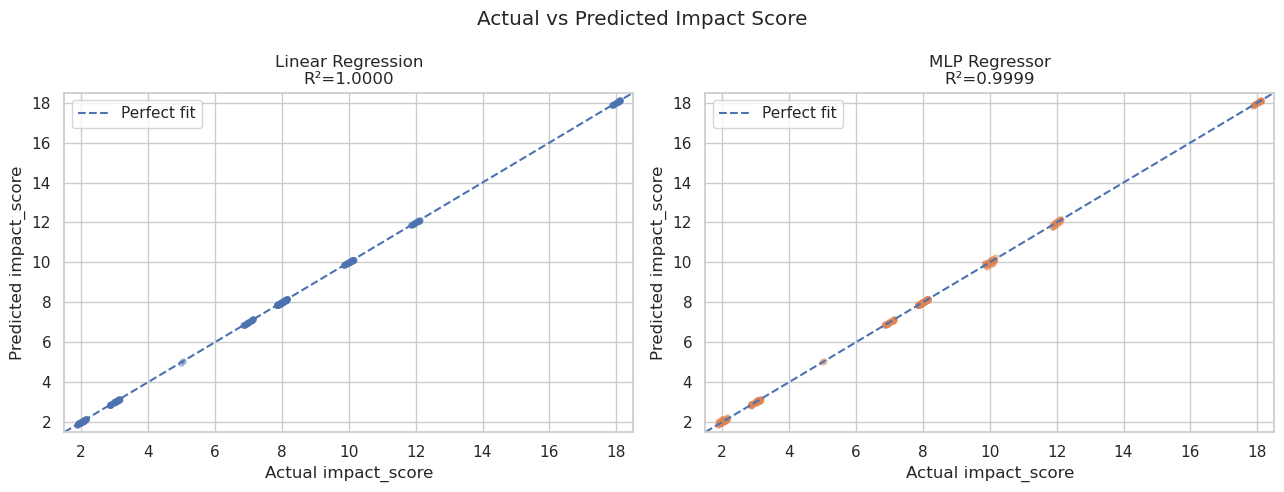

In [54]:
# plot 1: actual vs predicted

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
model_names = ["Linear Regression", "MLP Regressor"]

lo, hi = y.min() - 0.5, y.max() + 0.5

for ax, name, color in zip(axes, model_names, PALETTE):
    y_pred_plot = results[name]["y_pred"]

    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, size=len(y_test))

    ax.scatter(
        y_test + jitter,
        y_pred_plot + jitter,
        alpha=0.35,
        s=15,
        color=color
    )

    ax.plot([lo, hi], [lo, hi], linestyle="--", label="Perfect fit")

    ax.set_title(f"{name}\nR²={results[name]['test_r2']:.4f}")
    ax.set_xlabel("Actual impact_score")
    ax.set_ylabel("Predicted impact_score")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.legend()

plt.suptitle("Actual vs Predicted Impact Score")
save_fig(os.path.join(PLOTS_DIR, "pred_actual_vs_predicted.png"))

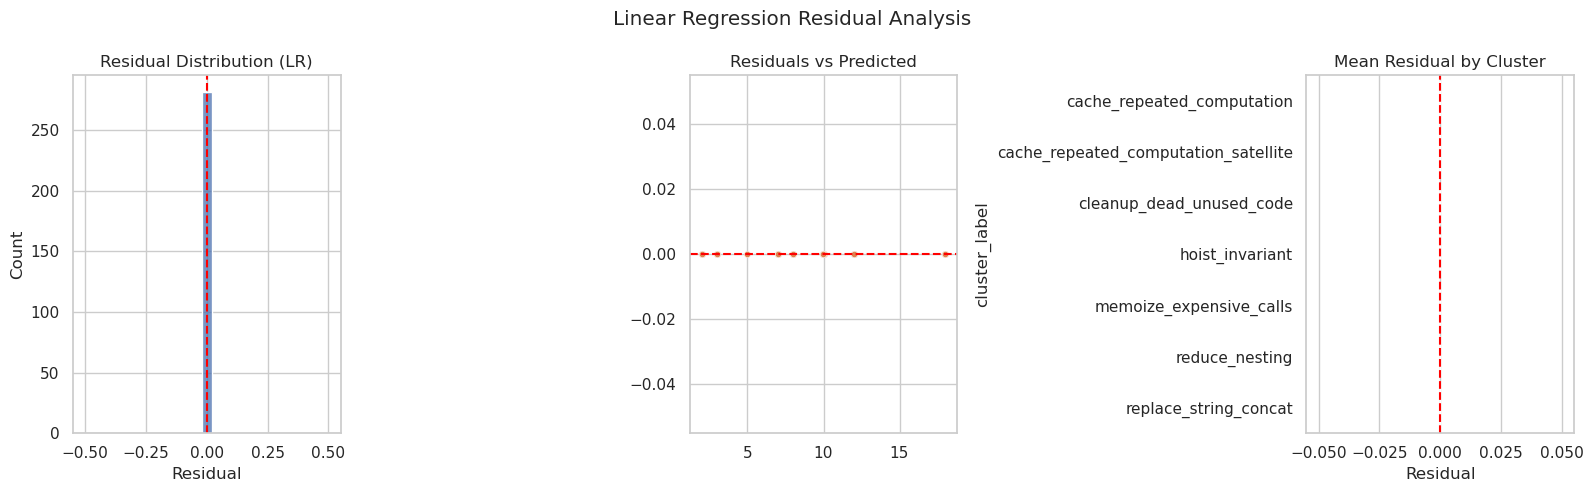

In [55]:
# plot 2: residual analysis

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

lr_residuals = y_test.values - results["Linear Regression"]["y_pred"]
lr_residuals = np.where(np.abs(lr_residuals) < 1e-10, 0.0, lr_residuals)

# histogram
sns.histplot(lr_residuals, bins=25, ax=axes[0], color=PALETTE[0])
axes[0].axvline(0, linestyle="--", color="red")
axes[0].set_title("Residual Distribution (LR)")
axes[0].set_xlabel("Residual")

# residual vs predicted
sns.scatterplot(
    x=results["Linear Regression"]["y_pred"],
    y=lr_residuals,
    ax=axes[1],
    color=PALETTE[1],
    s=20
)
axes[1].axhline(0, linestyle="--", color="red")
axes[1].set_title("Residuals vs Predicted")

# cluster residual means
full_res = np.where(np.abs(residuals.values) < 1e-10, 0.0, residuals.values)
cl_res_mean = df.assign(residual=full_res).groupby("cluster_label")["residual"].mean()

sns.barplot(
    x=cl_res_mean.values,
    y=cl_res_mean.index,
    ax=axes[2],
    palette=PALETTE
)
axes[2].axvline(0, linestyle="--", color="red")
axes[2].set_title("Mean Residual by Cluster")
axes[2].set_xlabel("Residual")

plt.suptitle("Linear Regression Residual Analysis")
save_fig(os.path.join(PLOTS_DIR, "pred_residuals.png"))

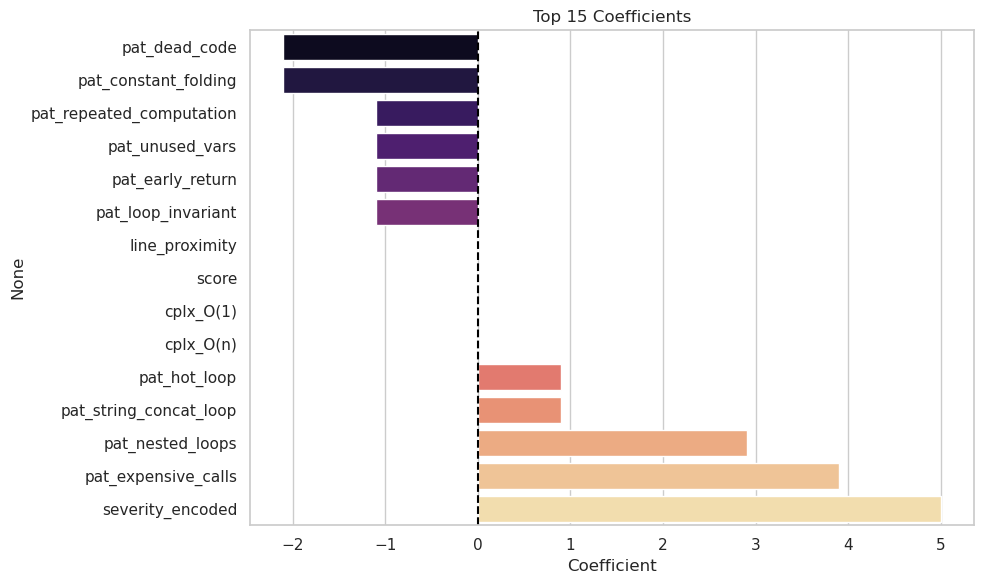

In [61]:
# plot 3: coefficients

lr_model = results["Linear Regression"]["model"]
coef = pd.Series(lr_model.coef_, index=ALL_FEATURES)

coef_top = coef.abs().sort_values(ascending=False).head(15).index
coef_plot = coef[coef_top].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x=coef_plot.values, y=coef_plot.index, palette="magma", ax=ax)
ax.axvline(0, linestyle="--", color="black")
ax.set_title("Top 15 Coefficients")
ax.set_xlabel("Coefficient")

save_fig(os.path.join(PLOTS_DIR, "pred_coefficients.png"))

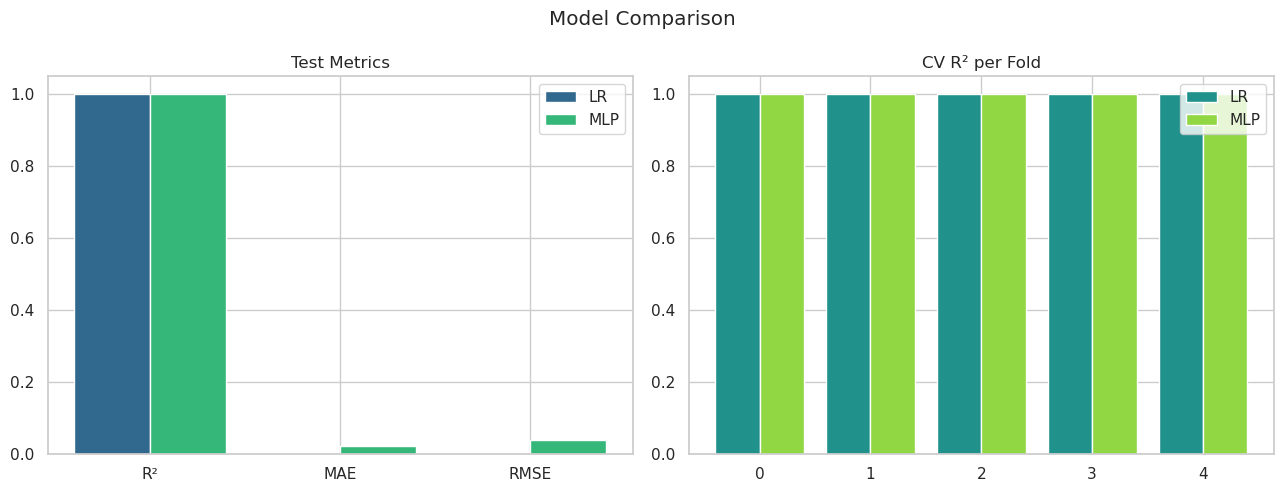

In [69]:
# plot 4: model comparison

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics = ["R²", "MAE", "RMSE"]

lr_vals = [
    results["Linear Regression"]["test_r2"],
    results["Linear Regression"]["test_mae"],
    results["Linear Regression"]["test_rmse"]
]

mlp_vals = [
    results["MLP Regressor"]["test_r2"],
    results["MLP Regressor"]["test_mae"],
    results["MLP Regressor"]["test_rmse"]
]

x = np.arange(len(metrics))

colors = sns.color_palette("viridis", 2)

axes[0].bar(x - 0.2, lr_vals, 0.4, label="LR", color=colors[0])
axes[0].bar(x + 0.2, mlp_vals, 0.4, label="MLP", color=colors[1])

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title("Test Metrics")
axes[0].legend()

fold_colors = sns.color_palette("viridis", 5)
folds = np.arange(5)

axes[1].bar(folds - 0.2,
            results["Linear Regression"]["cv_fold_r2"],
            0.4, label="LR", color=fold_colors[2])

axes[1].bar(folds + 0.2,
            results["MLP Regressor"]["cv_fold_r2"],
            0.4, label="MLP", color=fold_colors[4])

axes[1].set_title("CV R² per Fold")
axes[1].legend()

plt.suptitle("Model Comparison")
save_fig(os.path.join(PLOTS_DIR, "pred_model_comparison.png"))